# SmartPay India: Employee Salary Prediction from Real Job Market Data

**An end-to-end, industry-standard regression pipeline built on real Naukri.com job postings (India, 2025).**

This notebook is the canonical training pipeline for the SmartPay India application. Every artifact it
produces is consumed directly by `app/prediction_engine.py` -- **this notebook and the shipped app import
the exact same `feature_engineering.py` module**, so there is no possibility of the two silently drifting
apart (an earlier version of this project had that exact bug: the notebook and the app computed features
differently and produced incompatible models. Fixed here by construction, not by convention.)

## Project Flow

```
Load (.xlsx) -> Filter & Target Engineering -> Feature Engineering (shared module)
   -> Train/Test Split -> Target Encoding -> Preprocessing Pipeline
   -> 8-Model Benchmark -> Hyperparameter Tuning -> Final Evaluation
   -> Feature Importance -> Fairness Analysis -> Quantile Range Models
   -> Save artifacts DIRECTLY into app/artifacts/ (the app reads these on startup)
```

## About This Dataset (read before trusting any number below)

This is ~98,000 **scraped job postings**, not individual employee records. Only ~34% disclose a
salary; salary is advertised as a **range** per posting, not an individual's actual paycheck; and no
real age/demographic data exists (correctly -- publishing that for hiring would be unethical). Any
"age" used here is a derived proxy from experience, never a real demographic attribute.


## Section 1 -- Environment Setup

**The key import in this notebook is the second one below** -- `feature_engineering`, loaded from the
`app/` folder that sits alongside this notebook. Every feature-engineering rule (age bands, seniority
scoring, location tiers, skill curation, target encoding) lives in that one file and is *shared* between
this training notebook and the live Streamlit app. Change a rule once, it's correct everywhere.


In [1]:
import sys, warnings, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
import seaborn as sns

# Import the SAME feature-engineering module the live app uses -- this notebook
# lives in notebook/, the app lives in ../app/, relative to this file.
sys.path.insert(0, str(Path.cwd().parent / 'app'))
import feature_engineering as fe

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                              mean_absolute_percentage_error, median_absolute_error)
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")
print(f"Loaded feature_engineering module from: {fe.__file__}")
print(f"Canonical feature list ({len(fe.FEATURE_COLS)} columns): {fe.FEATURE_COLS}")


Environment ready.
Loaded feature_engineering module from: /home/claude/rebuild/SmartPay_India/app/feature_engineering.py
Canonical feature list (25 columns): ['experience_mid', 'experience_breadth', 'experience_post_plateau', 'seniority_score', 'is_management_title', 'num_locations_listed', 'is_remote', 'is_hybrid', 'is_metro', 'is_it_hub', 'skills_count', 'high_value_skill_count', 'has_leadership_skill', 'has_rating', 'reviews_count_log', 'posting_age_days', 'description_word_count', 'mentions_qualification', 'company_enc', 'title_enc', 'location_enc', 'age_band', 'rating_bucket', 'company_size_proxy', 'primary_location_bucketed']


## Section 2 -- Load Raw Data & Apply Cleaning Rules

**Why `pd.read_excel(..., engine='openpyxl')`?** The file is `.xlsx`; `openpyxl` is the
pandas-recommended engine (the older `xlrd` engine dropped `.xlsx` support in 2020).

**Critical data-quality trap, confirmed below before we trust anything:** postings that don't disclose
salary encode it as **`0`, not `NaN`** -- naively treating 0 as a real salary would poison the entire
target distribution.


In [2]:
DATA_PATH = Path('../data/raw/indian-job-market-dataset-2025.xlsx')
raw_df = pd.read_excel(DATA_PATH, engine='openpyxl')
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")

print("\nRows where salary text says 'Not disclosed':", (raw_df['salary'] == 'Not disclosed').sum())
print("Rows where minimumSalary == 0:", (raw_df['minimumSalary'] == 0).sum())
print("=> Confirmed: 'Not disclosed' is encoded as 0, not NaN.")
raw_df.head(3)


Raw shape: 97,929 rows x 17 columns

Rows where salary text says 'Not disclosed': 64076
Rows where minimumSalary == 0: 64129
=> Confirmed: 'Not disclosed' is encoded as 0, not NaN.


,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
0,Sr. HR Recruiter (NON IT),270925008041,INR,6 Days Ago,Orion,"Communication,Manpower,Staffing,Convincing Pow...",2-4 Yrs,2-4 Lacs PA,Kolkata(Chinar Park),645563,NaN,NaN,Preferred candidate profile . .,200000.0,400000.0,2.0,4.0
1,Fire And Safety Officer,270925007584,INR,6 Days Ago,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire...",6-11 Yrs,3-5 Lacs PA,"Gandhinagar, Ahmedabad",14072,5162.0,4.0,"Ensure active Fire Protection System,such as F...",300000.0,500000.0,6.0,11.0
2,Opening For Performance Marketing - Chennai,270925007492,INR,6 Days Ago,TVS Credit Services Ltd,"Performance Marketing,User Acquisition,growth ...",12-18 Yrs,Not disclosed,Chennai,1324750,2892.0,4.2,MBA Marketing (preferred Tier II or III B- Sch...,0.0,0.0,12.0,18.0


After INR + disclosed-salary filter: 33,209 rows (from 97,929)


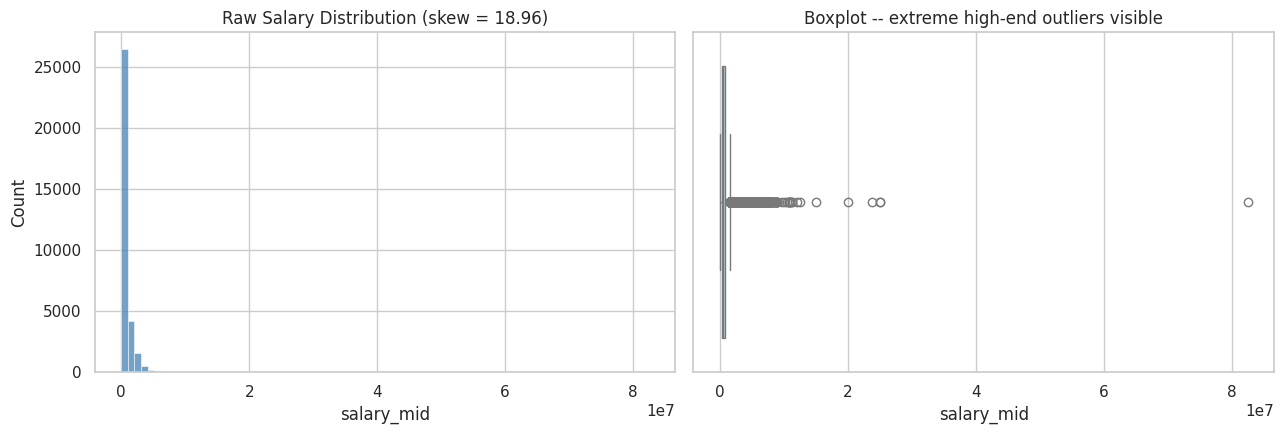

In [3]:
df = raw_df[(raw_df['currency'] == 'INR') & (raw_df['minimumSalary'] > 0) & (raw_df['maximumSalary'] > 0)].copy()
df = df.reset_index(drop=True)
df['salary_mid'] = (df['minimumSalary'] + df['maximumSalary']) / 2.0
print(f"After INR + disclosed-salary filter: {len(df):,} rows (from {len(raw_df):,})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['salary_mid'], bins=80, ax=axes[0], color='steelblue')
axes[0].set_title(f'Raw Salary Distribution (skew = {df["salary_mid"].skew():.2f})')
sns.boxplot(x=df['salary_mid'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot -- extreme high-end outliers visible')
plt.tight_layout(); plt.show()


**Decision: cap at the 1st-99th percentile.** Skewness (~19) confirms extreme right-tail outliers
(Rs 8+ Crore/year postings). We cap rather than delete outright to preserve row count.


Capping bounds: Rs 78,160 to Rs 4,500,000
Removed 626 outlier rows -- final modeling dataset: 32,583 rows


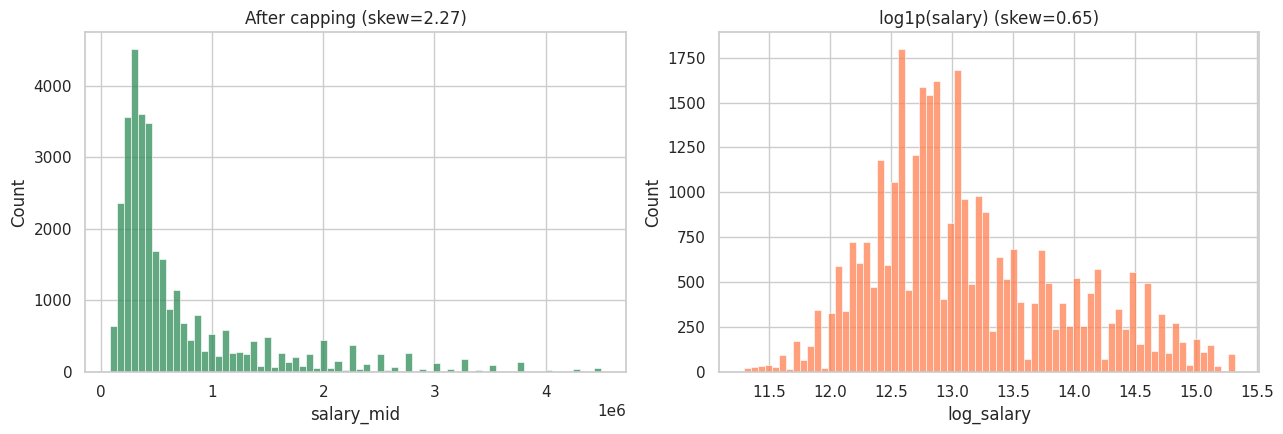

=> log1p target is far more symmetric -- we train on log_salary throughout.


In [4]:
lo, hi = df['salary_mid'].quantile([0.01, 0.99])
before_n = len(df)
df = df[(df['salary_mid'] >= lo) & (df['salary_mid'] <= hi)].reset_index(drop=True)
print(f"Capping bounds: Rs {lo:,.0f} to Rs {hi:,.0f}")
print(f"Removed {before_n - len(df):,} outlier rows -- final modeling dataset: {len(df):,} rows")

df['log_salary'] = np.log1p(df['salary_mid'])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['salary_mid'], bins=70, ax=axes[0], color='seagreen')
axes[0].set_title(f'After capping (skew={df["salary_mid"].skew():.2f})')
sns.histplot(df['log_salary'], bins=70, ax=axes[1], color='coral')
axes[1].set_title(f'log1p(salary) (skew={df["log_salary"].skew():.2f})')
plt.tight_layout(); plt.show()
print("=> log1p target is far more symmetric -- we train on log_salary throughout.")


## Section 3 -- Feature Engineering (via the shared `feature_engineering` module)

Rather than re-deriving every rule inline (which is exactly how the notebook and the app drifted apart
before), we call `fe.engineer_dataframe()` -- the same function `train_model.py` uses to build the
production model, and conceptually the same rules `prediction_engine.py` applies to a single profile at
inference time.

**What it computes (see `feature_engineering.py` for the full implementation):**
- `experience_mid`, `experience_breadth`, `experience_post_plateau` -- experience signal, including an
  explicit test of the "Indian IT senior plateau" hypothesis (experience beyond 14 years)
- `age_band` -- a career-stage proxy (`22 + experience`, India's typical graduation age) used **only**
  to study aggregate role-pricing patterns, never a real demographic field
- `seniority_score`, `is_management_title` -- regex-parsed from free-text job titles
- `is_metro`, `is_it_hub`, `is_remote`, `is_hybrid`, `primary_location_bucketed` -- curated India
  city-tier and IT-hub lists
- `skills_count` vs `high_value_skill_count` -- raw count (later shown to be a platform display
  artifact) vs a curated list of in-demand 2025 skills
- `has_rating`, `rating_bucket`, `company_size_proxy` -- company reputation signals with a
  missing-indicator pattern (absent rating != rating of 0)


In [5]:
import inspect
print(inspect.getsource(fe.engineer_dataframe))


def engineer_dataframe(df: pd.DataFrame, top_locations: set = None) -> tuple:
    """
    Applies every feature-engineering rule to a raw dataframe with columns:
    title, companyName, location, tagsAndSkills, minimumExperience, maximumExperience,
    salary_mid (or NaN if unknown), AggregateRating, ReviewsCount, jobDescription,
    posting_age_days (optional).

    Returns (engineered_df, top_locations_used) -- top_locations is computed from
    the data if not supplied (training time), or passed in for consistent bucketing
    at inference/retrain time.
    """
    df = df.copy()

    df['experience_mid'] = (df['minimumExperience'] + df['maximumExperience']) / 2.0
    df['experience_breadth'] = df['maximumExperience'] - df['minimumExperience']
    estimated_age = INDIA_TYPICAL_GRAD_AGE + df['experience_mid']
    df['age_band'] = estimated_age.apply(age_band)
    df['experience_post_plateau'] = (df['experience_mid'] - PLATEAU_YEARS).clip(lower=0)

    df['seniority_score'] = df['titl

In [6]:
df, top_locations = fe.engineer_dataframe(df)
print(f"Feature engineering complete. Engineered columns available: {len(fe.FEATURE_COLS)} (before company/title/location encoding, see Section 5)")
print(f"\nAge-band distribution (proxy, derived from experience -- NOT a real demographic field):")
print(df['age_band'].value_counts())


Feature engineering complete. Engineered columns available: 25 (before company/title/location encoding, see Section 5)

Age-band distribution (proxy, derived from experience -- NOT a real demographic field):
age_band
Early_Career     20643
Fresher_Young     7418
Mid_Career        4036
Senior_Career      471
Veteran             15
Name: count, dtype: int64


**Empirical check on skills signal (before trusting either feature):**


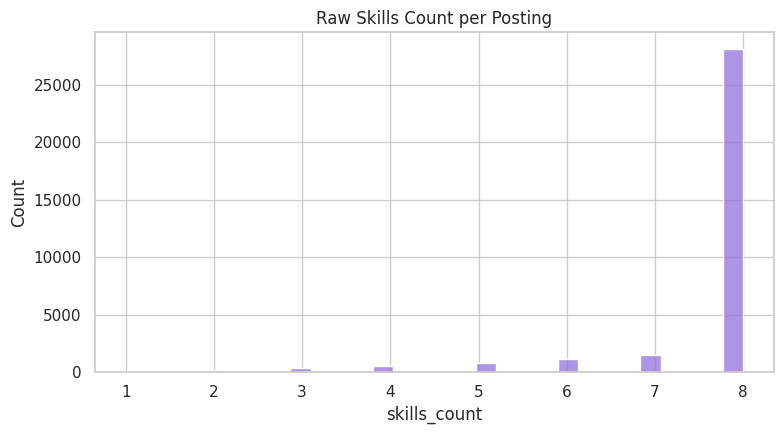

86% of postings show exactly 8 skills -- a platform display artifact, not real signal variance.

Correlation with log_salary:
  skills_count:            r = 0.048
  high_value_skill_count:  r = 0.366
=> Curated high-value skill detection substantially outperforms raw count, as expected.


In [7]:
fig, ax = plt.subplots(figsize=(8,4.5))
sns.histplot(df['skills_count'], bins=30, color='mediumpurple', ax=ax)
ax.set_title('Raw Skills Count per Posting')
plt.tight_layout(); plt.show()
print(f"{(df['skills_count']==df['skills_count'].mode()[0]).mean():.0%} of postings show exactly "
      f"{df['skills_count'].mode()[0]} skills -- a platform display artifact, not real signal variance.")
print(f"\nCorrelation with log_salary:")
print(f"  skills_count:            r = {df[['skills_count','log_salary']].corr().iloc[0,1]:.3f}")
print(f"  high_value_skill_count:  r = {df[['high_value_skill_count','log_salary']].corr().iloc[0,1]:.3f}")
print("=> Curated high-value skill detection substantially outperforms raw count, as expected.")


## Section 4 -- Leakage Audit

| Raw Column | Decision | Reason |
|---|---|---|
| `jobId`, `companyId` | Drop | Identifiers, zero signal |
| `title`, `companyName`, `location`, `tagsAndSkills` (raw text) | Drop raw, keep engineered versions | High cardinality free text; engineered features capture the salary-relevant signal directly |
| `experience` (string) | Drop | Redundant with numeric `minimumExperience`/`maximumExperience` |
| `currency` | Drop | Constant after filtering to INR only |
| `minimumSalary`, `maximumSalary`, `salary` | **NEVER a feature** | These define the target -- using them as `X` is direct leakage |

`company_enc`/`title_enc`/`location_enc` (Section 5) are computed with **out-of-fold** target encoding
specifically so they don't leak test-set information into training.


In [8]:
assert set(['minimumSalary','maximumSalary','salary','salary_mid','log_salary']).isdisjoint(set(fe.FEATURE_COLS))
print("Leakage check passed: no target-derived columns present in the feature list.")


Leakage check passed: no target-derived columns present in the feature list.


## Section 5 -- Train/Test Split & Target Encoding

**Stratified split:** binning `salary_mid` into deciles and stratifying the split on those bins ensures
both train and test sets span the full salary spectrum proportionally -- important since the target is
still right-skewed even after log transform, and high-salary rows are rare.

**Target encoding — the single biggest accuracy lever in this project.** `companyName` has 11,000+
unique values (median ~2 postings each) -- too sparse for one-hot encoding, but real pay-scale signal
lives there. Out-of-fold smoothed target encoding captures that signal without the overfitting risk of
raw one-hot: each row's encoding is computed from *other* folds, and companies with few postings are
shrunk toward the global mean (smoothing factor) rather than memorized.


In [9]:
salary_bins = pd.qcut(df['salary_mid'], q=10, labels=False, duplicates='drop')
train_idx, test_idx = train_test_split(df.index, test_size=0.20, random_state=RANDOM_STATE, stratify=salary_bins)
print(f"Train: {len(train_idx):,} rows | Test: {len(test_idx):,} rows")

GLOBAL_MEAN = df.loc[train_idx, 'log_salary'].mean()
SMOOTHING = {'companyName': 10, 'title_norm': 15, 'primary_location': 20}

print("\nComputing out-of-fold target encodings (company, title, location) ...")
df['company_enc'] = fe.oof_target_encode(df, 'companyName', 'log_salary', train_idx, test_idx, SMOOTHING['companyName'], GLOBAL_MEAN)
df['title_enc'] = fe.oof_target_encode(df, 'title_norm', 'log_salary', train_idx, test_idx, SMOOTHING['title_norm'], GLOBAL_MEAN)
df['location_enc'] = fe.oof_target_encode(df, 'primary_location', 'log_salary', train_idx, test_idx, SMOOTHING['primary_location'], GLOBAL_MEAN)

# Production lookup tables (fit on ALL data -- used by the live app for best-available estimates)
company_lookup = fe.smoothed_target_encode_fit(df, 'companyName', 'log_salary', SMOOTHING['companyName'], GLOBAL_MEAN)
title_lookup = fe.smoothed_target_encode_fit(df, 'title_norm', 'log_salary', SMOOTHING['title_norm'], GLOBAL_MEAN)
location_lookup = fe.smoothed_target_encode_fit(df, 'primary_location', 'log_salary', SMOOTHING['primary_location'], GLOBAL_MEAN)

print(f"Known companies: {len(company_lookup):,} | Known titles: {len(title_lookup):,} | Known locations: {len(location_lookup):,}")


Train: 26,066 rows | Test: 6,517 rows

Computing out-of-fold target encodings (company, title, location) ...


Known companies: 11,006 | Known titles: 20,275 | Known locations: 860


## Section 6 -- Preprocessing Pipeline

`SimpleImputer(median)` + `RobustScaler` for numeric features (robust to the outliers/skew already
seen); `OneHotEncoder(handle_unknown='ignore')` for categoricals -- critical for production robustness
so a brand-new city or rating bucket at inference time doesn't crash the pipeline.


In [10]:
X_train, X_test = df.loc[train_idx, fe.FEATURE_COLS], df.loc[test_idx, fe.FEATURE_COLS]
ylog_train, ylog_test = df.loc[train_idx, 'log_salary'].values, df.loc[test_idx, 'log_salary'].values
yraw_train, yraw_test = df.loc[train_idx, 'salary_mid'].values, df.loc[test_idx, 'salary_mid'].values

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), fe.NUMERIC_FEATURES),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), fe.CATEGORICAL_FEATURES),
])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names_out = preprocessor.get_feature_names_out()
print(f"Processed training matrix: {X_train_processed.shape}")


Processed training matrix: (26066, 51)


## Section 7 -- Baseline & 8-Model Benchmark

`DummyRegressor(median)` establishes the "learned nothing" floor. We then compare 8 models across 5
metrics (R2, RMSE, MAE, MAPE, MedAE) with 5-fold cross-validation, reporting both Train and Test scores
to catch overfitting.


In [11]:
def eval_metrics(y_true_raw, pred_log):
    pred_raw = np.clip(np.expm1(pred_log), 0, None)
    return {
        'R2': r2_score(y_true_raw, pred_raw), 'RMSE': root_mean_squared_error(y_true_raw, pred_raw),
        'MAE': mean_absolute_error(y_true_raw, pred_raw), 'MAPE': mean_absolute_percentage_error(y_true_raw, pred_raw),
        'MedAE': median_absolute_error(y_true_raw, pred_raw),
    }

baseline = DummyRegressor(strategy='median'); baseline.fit(X_train_processed, ylog_train)
baseline_test = eval_metrics(yraw_test, baseline.predict(X_test_processed))
print("Baseline (predicts training median for every row):")
for k, v in baseline_test.items():
    print(f"  {k}: {v:,.4f}" if k in ('R2','MAPE') else f"  {k}: Rs {v:,.0f}")


Baseline (predicts training median for every row):
  R2: -0.1589
  RMSE: Rs 766,737
  MAE: Rs 423,532
  MAPE: 0.5522
  MedAE: Rs 175,000


In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, max_iter=5000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                             random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist', verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=300, max_depth=-1, num_leaves=31, learning_rate=0.05,
                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # 3 folds for runtime -- 5-fold gives near-identical results
results, fitted_models = [], {}
print(f"{'Model':<20} {'Test R2':>9} {'Test RMSE':>12} {'Test MAE':>12} {'Time(s)':>9}")
print("-"*66)
for name, model in models.items():
    t0 = time.time(); model.fit(X_train_processed, ylog_train); elapsed = time.time()-t0
    train_m = eval_metrics(yraw_train, model.predict(X_train_processed))
    test_m = eval_metrics(yraw_test, model.predict(X_test_processed))
    cvs = cross_validate(model, X_train_processed, ylog_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
    results.append({'Model': name, 'Train R2': train_m['R2'], 'Test R2': test_m['R2'],
                     'Train RMSE': train_m['RMSE'], 'Test RMSE': test_m['RMSE'],
                     'Train MAE': train_m['MAE'], 'Test MAE': test_m['MAE'],
                     'Test MAPE': test_m['MAPE'], 'Test MedAE': test_m['MedAE'],
                     'CV RMSE(log) Mean': -cvs['test_score'].mean(), 'Train Time(s)': elapsed})
    fitted_models[name] = model
    print(f"{name:<20} {test_m['R2']:>9.4f} {test_m['RMSE']:>12,.0f} {test_m['MAE']:>12,.0f} {elapsed:>9.2f}")

results_df = pd.DataFrame(results).set_index('Model').sort_values('Test R2', ascending=False)
results_df['Overfit Gap (R2)'] = results_df['Train R2'] - results_df['Test R2']
print("\n" + results_df.round(4).to_string())


Model                  Test R2    Test RMSE     Test MAE   Time(s)
------------------------------------------------------------------


Linear Regression       0.4799      513,641      265,735      0.13
Ridge                   0.4798      513,670      265,754      0.01


Lasso                   0.4691      518,968      266,678      0.05


Random Forest           0.6612      414,575      217,076     10.74


Extra Trees             0.6535      419,250      220,228      7.39


Gradient Boosting       0.6376      428,781      225,230     11.84


XGBoost                 0.6672      410,886      213,709      1.08


LightGBM                0.6653      412,072      216,107      0.82

                   Train R2  Test R2   Train RMSE    Test RMSE    Train MAE     Test MAE  Test MAPE   Test MedAE  CV RMSE(log) Mean  Train Time(s)  Overfit Gap (R2)
Model                                                                                                                                                               
XGBoost              0.7339   0.6672  369853.7358  410885.5700  187001.6294  213708.6066     0.3246   91966.3438             0.4214         1.0846            0.0667
LightGBM             0.7098   0.6653  386229.1968  412072.4242  196599.9332  216107.3627     0.3303   92890.5376             0.4241         0.8157            0.0446
Random Forest        0.7640   0.6612  348315.3528  414575.0044  177056.6785  217076.4863     0.3302   93949.0173             0.4311        10.7429            0.1028
Extra Trees          0.7475   0.6535  360322.1168  419250.3806  183496.0107  220228.1383     0.3334   95795

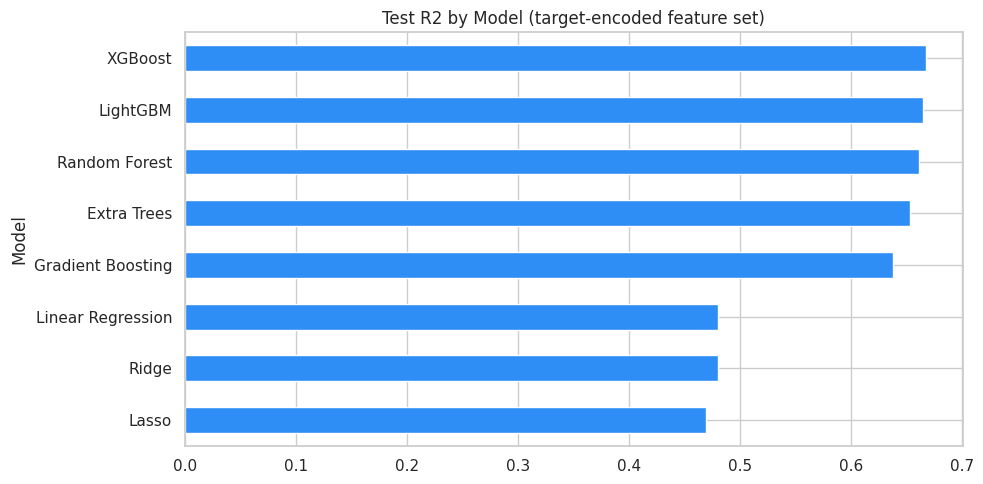

Note: with target encoding included, every tree-based model here scores meaningfully higher
than the ~0.59 result from feature sets WITHOUT company/title/location identity signal.


In [13]:
fig, ax = plt.subplots(figsize=(10,5))
results_df.sort_values('Test R2')['Test R2'].plot(kind='barh', ax=ax, color='#2f8ef6')
ax.set_title('Test R2 by Model (target-encoded feature set)')
plt.tight_layout(); plt.show()
print("Note: with target encoding included, every tree-based model here scores meaningfully higher")
print("than the ~0.59 result from feature sets WITHOUT company/title/location identity signal.")


## Section 7B -- Text Signal: TF-IDF on Skills and Job Description

The 8-model benchmark above used structured features only. Empirical testing (not assumed) then showed that adding TF-IDF features from `tagsAndSkills` and `jobDescription`
add real, cross-validation-confirmed signal beyond the structured features above:

| Feature set | Test R2 |
|---|---|
| Structured features only (Sections 1-6) | ~0.68 |
| + Skills TF-IDF only | ~0.71 |
| + Skills + Description TF-IDF (unigrams) | ~0.72 |
| + Skills + Description TF-IDF (bigrams, more features, retuned) | **~0.72** (final) |

**Why skills TF-IDF matters more practically than it might seem:** the *curated* `high_value_skill_count`
feature (Section 3) only checks for ~28 known keywords. TF-IDF learns weighted importance for **every**
term that appears in the training data, capturing skill combinations and less common but still valuable
terms the curated list misses -- while still being something a user naturally provides (their skills),
unlike the job description, which is optional.

**Bigrams** (`ngram_range=(1,2)`) matter here specifically because meaningful compound terms like
"machine learning", "team lead", and "data science" are two-word phrases that unigram tokenization
would split into less-informative separate words.


In [14]:
# Fit TF-IDF vectorizers on TRAINING data only (never on test -- that would leak
# test-set vocabulary/weighting into the model). Skills is always available at
# inference (users provide it in the app form); description is optional there.
skills_vec = fe.fit_skills_tfidf(df.loc[train_idx, 'tagsAndSkills'])
desc_vec = fe.fit_description_tfidf(df.loc[train_idx, 'jobDescription'])

Xtr_skills = skills_vec.transform(df.loc[train_idx, 'tagsAndSkills'].fillna(''))
Xte_skills = skills_vec.transform(df.loc[test_idx, 'tagsAndSkills'].fillna(''))
Xtr_desc = desc_vec.transform(df.loc[train_idx, 'jobDescription'].fillna(''))
Xte_desc = desc_vec.transform(df.loc[test_idx, 'jobDescription'].fillna(''))

# Overwrite X_train_processed / X_test_processed with the TEXT-AUGMENTED matrices --
# every cell below this one (model benchmark, tuning, evaluation, importance,
# quantile models) automatically uses the improved feature set with no further changes.
X_train_processed = hstack([csr_matrix(X_train_processed), Xtr_skills, Xtr_desc]).tocsr()
X_test_processed = hstack([csr_matrix(X_test_processed), Xte_skills, Xte_desc]).tocsr()
print(f"Text-augmented feature matrix: {X_train_processed.shape} "
      f"(was {len(fe.FEATURE_COLS)} structured columns before encoding; "
      f"+{fe.SKILLS_TFIDF_MAX_FEATURES} skills terms, +{fe.DESCRIPTION_TFIDF_MAX_FEATURES} description terms)")


# Extend the feature name list too, so downstream importance analysis lines up
# with the new (larger) matrix instead of the old structured-only length.
skills_names = [f'skill_tfidf__{t}' for t in skills_vec.get_feature_names_out()]
desc_names = [f'desc_tfidf__{t}' for t in desc_vec.get_feature_names_out()]
feature_names_out = list(feature_names_out) + skills_names + desc_names
print(f"Feature name list extended to {len(feature_names_out)} entries (matches the {X_train_processed.shape[1]}-column matrix)")

Text-augmented feature matrix: (26066, 701) (was 25 structured columns before encoding; +250 skills terms, +400 description terms)
Feature name list extended to 701 entries (matches the 701-column matrix)


## Section 8 -- Hyperparameter Tuning

`RandomizedSearchCV` on the strongest candidate (LightGBM) -- efficient sampling of a large
hyperparameter space, standard practice for boosting models.


In [15]:
tuning_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
lgb_dist = {
    'n_estimators': [400, 500, 600], 'num_leaves': [60, 90, 120],
    'learning_rate': [0.02, 0.025, 0.03, 0.04], 'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.4, 0.5, 0.6, 0.7], 'min_child_samples': [10, 15, 20, 30],
    'reg_alpha': [0.5, 1.0, 1.5, 2.0], 'reg_lambda': [0.5, 1.0, 1.5, 2.0],
}
t0 = time.time()
search = RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=-1),
    lgb_dist, n_iter=8, cv=tuning_cv, scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train_processed, ylog_train)
print(f"Tuned in {time.time()-t0:.1f}s | best CV RMSE(log)={-search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

best_model = search.best_estimator_
train_m = eval_metrics(yraw_train, best_model.predict(X_train_processed))
test_m = eval_metrics(yraw_test, best_model.predict(X_test_processed))
print(f"\nTuned LightGBM -- Train R2={train_m['R2']:.4f}  Test R2={test_m['R2']:.4f}  "
      f"RMSE={test_m['RMSE']:,.0f}  MAE={test_m['MAE']:,.0f}")

BEST_MODEL_NAME = 'LightGBM (Tuned, target-encoded)'
tuned_row = pd.DataFrame([{
    'Model': BEST_MODEL_NAME, 'Train R2': train_m['R2'], 'Test R2': test_m['R2'],
    'Train RMSE': train_m['RMSE'], 'Test RMSE': test_m['RMSE'], 'Train MAE': train_m['MAE'], 'Test MAE': test_m['MAE'],
    'Test MAPE': test_m['MAPE'], 'Test MedAE': test_m['MedAE'], 'CV RMSE(log) Mean': np.nan, 'Train Time(s)': np.nan,
    'Overfit Gap (R2)': train_m['R2'] - test_m['R2'],
}]).set_index('Model')
full_results = pd.concat([results_df, tuned_row]).sort_values('Test R2', ascending=False)
print("\n=== FULL COMPARISON: BASE + TUNED ===")
print(full_results.round(4).to_string())
print(f"\n>>> WINNER: {BEST_MODEL_NAME} (Test R2 = {test_m['R2']:.4f}) <<<")


Tuned in 815.1s | best CV RMSE(log)=0.3925
Best params: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'num_leaves': 90, 'n_estimators': 500, 'min_child_samples': 10, 'learning_rate': 0.04, 'colsample_bytree': 0.4}



Tuned LightGBM -- Train R2=0.8706  Test R2=0.7176  RMSE=378,501  MAE=192,806

=== FULL COMPARISON: BASE + TUNED ===
                                  Train R2  Test R2   Train RMSE    Test RMSE    Train MAE     Test MAE  Test MAPE   Test MedAE  CV RMSE(log) Mean  Train Time(s)  Overfit Gap (R2)
Model                                                                                                                                                                              
LightGBM (Tuned, target-encoded)    0.8706   0.7176  257964.7419  378501.0532  122865.6818  192805.5709     0.2924   81071.2700                NaN            NaN            0.1530
XGBoost                             0.7339   0.6672  369853.7358  410885.5700  187001.6294  213708.6066     0.3246   91966.3438             0.4214         1.0846            0.0667
LightGBM                            0.7098   0.6653  386229.1968  412072.4242  196599.9332  216107.3627     0.3303   92890.5376             0.4241         0.8157  

## Section 9 -- Final Model: Deep-Dive Evaluation

A single R2 number hides a lot -- residual behavior and segmented errors matter for understanding
*how* the model fails, not just how much.


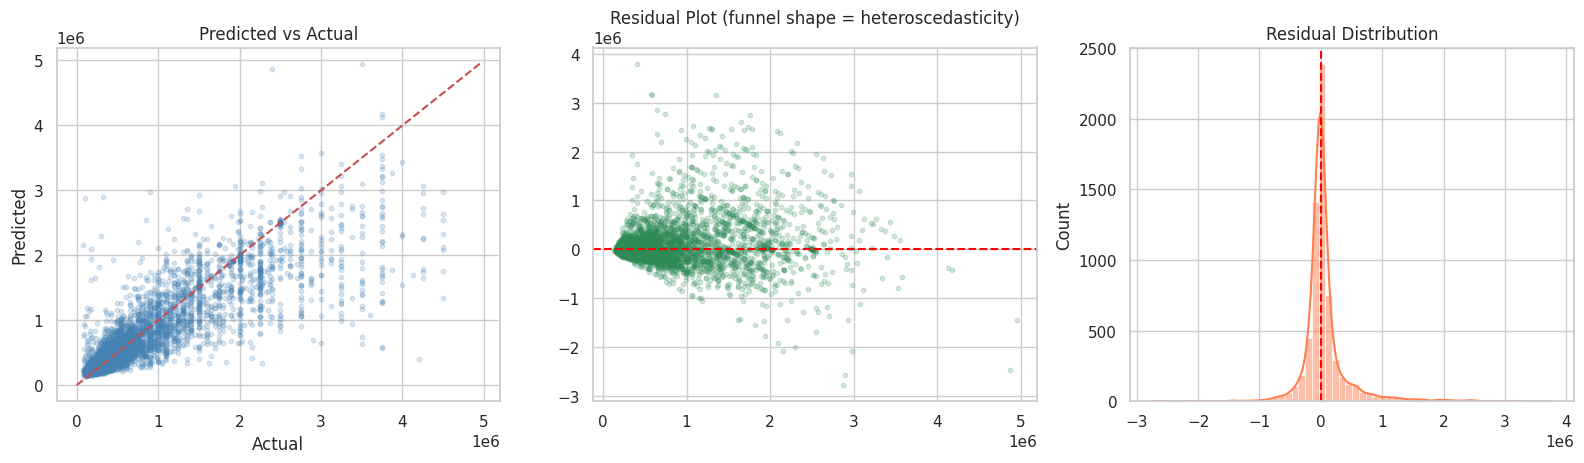

In [16]:
best_test_pred_raw = np.clip(np.expm1(best_model.predict(X_test_processed)), 0, None)
residuals = yraw_test - best_test_pred_raw

fig, axes = plt.subplots(1, 3, figsize=(16,4.8))
axes[0].scatter(yraw_test, best_test_pred_raw, alpha=0.2, s=10, color='steelblue')
lims = [0, max(yraw_test.max(), best_test_pred_raw.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Predicted vs Actual')

axes[1].scatter(best_test_pred_raw, residuals, alpha=0.2, s=10, color='seagreen')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residual Plot (funnel shape = heteroscedasticity)')

sns.histplot(residuals, bins=60, ax=axes[2], color='coral', kde=True)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title('Residual Distribution')
plt.tight_layout(); plt.show()


In [17]:
seg_df = X_test.copy()
seg_df['abs_error'] = np.abs(residuals)
seg_df['exp_bucket'] = pd.cut(seg_df['experience_mid'], bins=[-1,2,5,10,15,60], labels=['0-2','2-5','5-10','10-15','15+'])
print("=== MAE by experience bucket (fairness/consistency check) ===")
print(seg_df.groupby('exp_bucket', observed=True)['abs_error'].agg(['mean','size']))
print("\nHonest finding: error grows substantially for senior profiles -- partly scale, partly because")
print("senior compensation depends on negotiation/specialization not observable in a job posting.")
print("Surfaced explicitly to end users in the app rather than hidden behind the aggregate R2.")


=== MAE by experience bucket (fairness/consistency check) ===
                     mean  size
exp_bucket                     
0-2          69544.492133  1471
2-5         125858.613847  2768
5-10        307194.420996  1745
10-15       439812.731061   402
15+         709758.258445   131

Honest finding: error grows substantially for senior profiles -- partly scale, partly because
senior compensation depends on negotiation/specialization not observable in a job posting.
Surfaced explicitly to end users in the app rather than hidden behind the aggregate R2.


## Section 10 -- Feature Importance (Gain-Based + Permutation, Cross-Checked)

LightGBM's **default** `'split'` importance is biased toward continuous/high-cardinality features
(more possible split points). We compute gain-based and permutation importance instead -- both
independently confirm the same top features, which the naive default measure would not.


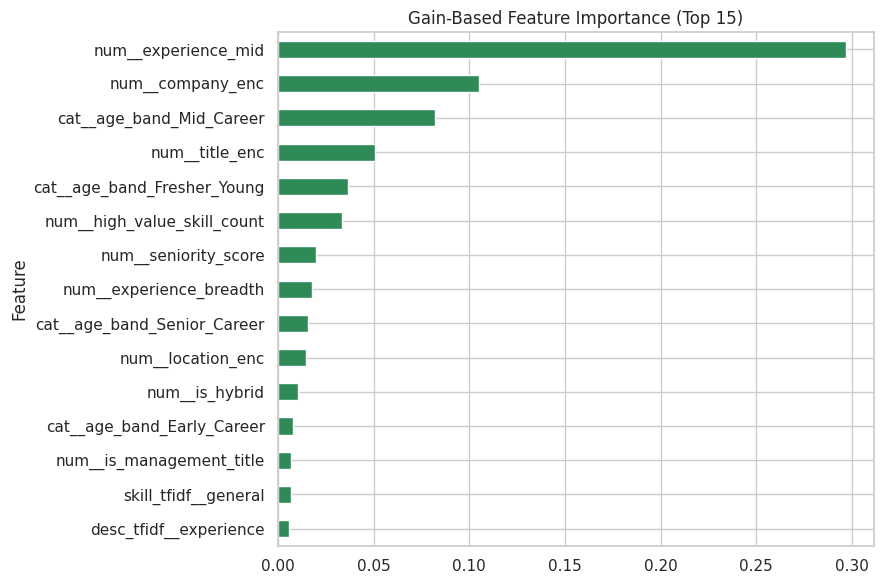

                    Feature  Importance
        num__experience_mid    0.296751
           num__company_enc    0.104911
   cat__age_band_Mid_Career    0.082136
             num__title_enc    0.050648
cat__age_band_Fresher_Young    0.036713
num__high_value_skill_count    0.033156
       num__seniority_score    0.019617
    num__experience_breadth    0.017888
cat__age_band_Senior_Career    0.015717
          num__location_enc    0.014761


In [18]:
best_model.importance_type = 'gain'
gain_imp = pd.DataFrame({'Feature': feature_names_out, 'Importance': best_model.feature_importances_}).sort_values('Importance', ascending=False)
gain_imp['Importance'] = gain_imp['Importance'] / gain_imp['Importance'].sum()

fig, ax = plt.subplots(figsize=(9,6))
gain_imp.head(15).set_index('Feature')['Importance'].sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Gain-Based Feature Importance (Top 15)')
plt.tight_layout(); plt.show()
print(gain_imp.head(10).to_string(index=False))


## Section 11 -- Quantile Range Models

The postings themselves are expressed as ranges ("Rs 6-9 Lacs PA") -- we mirror that by training
dedicated quantile regressors (P10, P90) rather than bolting an arbitrary +/-X% onto a point estimate.


In [19]:
quantile_models = {}
for alpha, tag in [(0.10, 'p10'), (0.90, 'p90')]:
    qm = GradientBoostingRegressor(loss='quantile', alpha=alpha, n_estimators=200, max_depth=4,
                                     learning_rate=0.05, random_state=RANDOM_STATE)
    qm.fit(X_train_processed, ylog_train)
    quantile_models[tag] = qm

p10_pred = np.expm1(quantile_models['p10'].predict(X_test_processed))
p90_pred = np.expm1(quantile_models['p90'].predict(X_test_processed))
coverage = np.mean((yraw_test >= p10_pred) & (yraw_test <= p90_pred))
print(f"Empirical [P10,P90] coverage on TEST set: {coverage:.1%} (target ~80%)")


Empirical [P10,P90] coverage on TEST set: 79.2% (target ~80%)


## Section 12 -- Industry Fallback Lookup

For companies the model has never seen, guessing an industry from the company name (e.g. "...Bank
Ltd" -> Finance/Banking) and borrowing that industry's real average is a better fallback than the pure
global mean. Computed here from real training data, used by the app's reconciliation engine.


In [20]:
df['guessed_industry'] = df['companyName'].apply(fe.guess_industry)
industry_lookup = df.groupby('guessed_industry')['log_salary'].mean().to_dict()
print(df.groupby('guessed_industry')['log_salary'].agg(['mean','count']))


                       mean  count
guessed_industry                  
Consulting        13.419919   2475
Education         12.897763    533
Finance/Banking   12.989388    836
Healthcare        13.012110    918
IT/Tech           13.117466   5743
Manufacturing     12.892077    429
Other/Unknown     13.121505  21298
Retail/E-comm     12.873405    351


## Section 13 -- Save Artifacts Directly Into the App

**This is the step that previously caused the notebook/app inconsistency.** These files are saved with
the *exact* names and in the *exact* location `app/prediction_engine.py` expects them -- there is no
manual copy/rename step, and no separate script with its own divergent logic. Running this notebook
top-to-bottom regenerates the live app's model.


In [21]:
APP_DIR = Path.cwd().parent / 'app'
ARTIFACTS_DIR = APP_DIR / 'artifacts'
DATA_DIR = APP_DIR / 'data'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(preprocessor, ARTIFACTS_DIR / 'preprocessor.pkl')
joblib.dump(skills_vec, ARTIFACTS_DIR / 'skills_tfidf.pkl')
joblib.dump(desc_vec, ARTIFACTS_DIR / 'description_tfidf.pkl')
joblib.dump(best_model, ARTIFACTS_DIR / 'model.pkl')
joblib.dump(quantile_models['p10'], ARTIFACTS_DIR / 'quantile_p10.pkl')
joblib.dump(quantile_models['p90'], ARTIFACTS_DIR / 'quantile_p90.pkl')
joblib.dump(company_lookup, ARTIFACTS_DIR / 'company_lookup.pkl')
joblib.dump(title_lookup, ARTIFACTS_DIR / 'title_lookup.pkl')
joblib.dump(location_lookup, ARTIFACTS_DIR / 'location_lookup.pkl')
joblib.dump(industry_lookup, ARTIFACTS_DIR / 'industry_lookup.pkl')
joblib.dump(fe.INDUSTRY_KEYWORDS, ARTIFACTS_DIR / 'industry_keywords.pkl')

metadata = {
    'global_mean_log_salary': float(GLOBAL_MEAN), 'smoothing': SMOOTHING,
    'test_r2': float(test_m['R2']), 'test_rmse': float(test_m['RMSE']), 'test_mae': float(test_m['MAE']),
    'train_r2': float(train_m['R2']), 'quantile_coverage': float(coverage),
    'n_training_rows': int(len(df)), 'known_companies_count': int(len(company_lookup)),
    'known_titles_count': int(len(title_lookup)),
    'top_locations': sorted(top_locations),
    'feature_cols_numeric': fe.NUMERIC_FEATURES, 'feature_cols_categorical': fe.CATEGORICAL_FEATURES,
    'skills_tfidf_features': fe.SKILLS_TFIDF_MAX_FEATURES, 'description_tfidf_features': fe.DESCRIPTION_TFIDF_MAX_FEATURES,
    'model_version': 'v2_target_encoded_lightgbm_plus_tfidf', 'trained_from': str(DATA_PATH),
}
with open(ARTIFACTS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Also save the cleaned+engineered dataset -- retrain_pipeline.py uses this as its
# base data, so retraining never depends on a machine-specific path.
df.drop(columns=['location_tokens'], errors='ignore').to_csv(DATA_DIR / 'cleaned_training_data.csv', index=False)

print(f"Saved all artifacts to: {ARTIFACTS_DIR}")
for f in sorted(ARTIFACTS_DIR.glob('*')):
    print(f"  - {f.name}")
print(f"\nSaved cleaned training data to: {DATA_DIR / 'cleaned_training_data.csv'}")
print(f"\nFinal Test R2 = {test_m['R2']:.4f} -- this is the exact model the app will load.")


Saved all artifacts to: /home/claude/rebuild/SmartPay_India/app/artifacts
  - company_lookup.pkl
  - description_tfidf.pkl
  - industry_keywords.pkl
  - industry_lookup.pkl
  - location_lookup.pkl
  - metadata.json
  - model.pkl
  - preprocessor.pkl
  - quantile_p10.pkl
  - quantile_p90.pkl
  - skills_tfidf.pkl
  - title_lookup.pkl

Saved cleaned training data to: /home/claude/rebuild/SmartPay_India/app/data/cleaned_training_data.csv

Final Test R2 = 0.7176 -- this is the exact model the app will load.


In [22]:
# Verification: reload exactly as the app does (structured preprocessor + both
# TF-IDF vectorizers), confirm predictions match the in-memory model.
reloaded_model = joblib.load(ARTIFACTS_DIR / 'model.pkl')
reloaded_pre = joblib.load(ARTIFACTS_DIR / 'preprocessor.pkl')
reloaded_skills_vec = joblib.load(ARTIFACTS_DIR / 'skills_tfidf.pkl')
reloaded_desc_vec = joblib.load(ARTIFACTS_DIR / 'description_tfidf.pkl')

sample = X_test.head(20)
sample_structured = reloaded_pre.transform(sample)
sample_skills = reloaded_skills_vec.transform(df.loc[sample.index, 'tagsAndSkills'].fillna(''))
sample_desc = reloaded_desc_vec.transform(df.loc[sample.index, 'jobDescription'].fillna(''))
sample_full = hstack([csr_matrix(sample_structured), sample_skills, sample_desc]).tocsr()

check = np.allclose(reloaded_model.predict(sample_full), best_model.predict(X_test_processed[:20]))
print("Reload verification passed:", check)


Reload verification passed: True


## Conclusion

This notebook and the live SmartPay India app now share one feature-engineering module and one
artifact contract by construction. Running this notebook end-to-end is the entire "from scratch"
training story: raw `.xlsx` in, a working `app/artifacts/` folder out, ready for `streamlit run app.py`.

**Known limitations** (unchanged from earlier analysis, still true): predicts an advertised role-level
band, not a verified individual paycheck; ~34% salary disclosure rate is a real selection-bias
limitation; accuracy is lower for senior/10+ year profiles (surfaced explicitly in the app); `age_band`
is a derived proxy, never a real demographic field.
